# Causal discovery

자동차 공학에서 중요한 주제중 하나는
차량 연비(miles per gallon, mpg)를 결정하는 요인 간 구조를 이해하는 것입니다.

이를 위해 UCI Auto MPG 데이터셋을 활용해

- LiNGAM
- PC
- GES

세 가지 인과 발견 알고리즘으로 DAG 구조를 추론하고,  
이를 도메인 지식과 비교하여 
특정 요인이 연비에 미치는 인과 효과를 추정하는 전 과정을 살펴봅니다.

In [2]:
import numpy as np
import pandas as pd
import graphviz
import networkx as nx

from lingam import DirectLiNGAM
from causallearn.search.ConstraintBased.PC import pc
from causallearn.search.ScoreBased.GES import ges
from dowhy import CausalModel

np.set_printoptions(precision=3, suppress=True)
np.random.seed(0)

/Users/hc.cho/Projects/awesome-causal-inference-python/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Data Setup

UCI Auto MPG 데이터셋은 1970–80년대 북미 시장을 중심으로 수집된  
자동차 스펙과 연비 정보를 담고 있습니다.

다음 6개 변수를 사용합니다.

- `mpg`: 연비 (target 변수)
- `cylinders`: 실린더 수
- `displacement`: 배기량
- `horsepower`: 출력 (마력)
- `weight`: 차량 중량
- `acceleration`: 0–60 mph 가속 시간 (초)

In [3]:
data_mpg = pd.read_csv(
    "http://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data-original",
    delim_whitespace=True,
    header=None,
    names=[
        "mpg", "cylinders", "displacement", "horsepower",
        "weight", "acceleration", "model_year", "origin", "car_name"
    ]
)

print("Raw shape:", data_mpg.shape)
data_mpg.head()

/var/folders/fw/d6t_wpzj2zb9lyd3st5l4dfm0000gn/T/ipykernel_39769/3414311417.py:1: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data_mpg = pd.read_csv(


Raw shape: (406, 9)


,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,car_name
0,18.0,8.0,307.0,130.0,3504.0,12.0,70.0,1.0,chevrolet chevelle malibu
1,15.0,8.0,350.0,165.0,3693.0,11.5,70.0,1.0,buick skylark 320
2,18.0,8.0,318.0,150.0,3436.0,11.0,70.0,1.0,plymouth satellite
3,16.0,8.0,304.0,150.0,3433.0,12.0,70.0,1.0,amc rebel sst
4,17.0,8.0,302.0,140.0,3449.0,10.5,70.0,1.0,ford torino


In [4]:
print("결측 개수:")
print(data_mpg.isna().sum())

data_clean = data_mpg.dropna().reset_index(drop=True)

data_small = data_clean.drop(["model_year", "origin", "car_name"], axis=1)

print("\n전처리 후 shape:", data_small.shape)
data_small.head()


결측 개수:
mpg             8
cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
model_year      0
origin          0
car_name        0
dtype: int64

전처리 후 shape: (392, 6)


,mpg,cylinders,displacement,horsepower,weight,acceleration
0,18.0,8.0,307.0,130.0,3504.0,12.0
1,15.0,8.0,350.0,165.0,3693.0,11.5
2,18.0,8.0,318.0,150.0,3436.0,11.0
3,16.0,8.0,304.0,150.0,3433.0,12.0
4,17.0,8.0,302.0,140.0,3449.0,10.5


## Causal Discovery

사용할 인과 발견 알고리즘은 다음과 같습니다.

1. **LiNGAM (DirectLiNGAM)**  
   - Function-based approach로 회귀 기반으로 구조와 계수를 함께 학습  
   - 선형 구조 + 비가우시안 잡음(non-Gaussian noise) 가정  
   - 인과 방향을 직접 식별하며, 완전한 DAG를 반환합니다.

2. **PC (Peter–Clark) 알고리즘**  
   - Constraint-based approach로 모든 변수가 연결된 그래프에서 시작  
   - 조건부 독립성(Conditional Independence) 테스트로  
     불필요한 엣지를 제거하고, v-structure를 이용해 방향을 부여  
   - 결과는 보통 Markov equivalence class(방향이 유일하게 정해지지 않는) 수준입니다.

3. **GES (Greedy Equivalence Search)**  
   - Score-based approach로 비어 있는 그래프에서 시작 
   - BIC 등 score function을 최대화하는 방향으로  
     엣지를 추가/삭제하는 greedy 탐색을 수행  
   - 마찬가지로 equivalence class 수준의 구조를 찾습니다.

In [5]:
X = data_small.values
feature_names = list(data_small.columns)

print("Features:", feature_names)
print("X shape :", X.shape)

Features: ['mpg', 'cylinders', 'displacement', 'horsepower', 'weight', 'acceleration']
X shape : (392, 6)


### Helper functions

각 인과 발견 알고리즘이 반환한 adjacency matrix를

- `graphviz.Digraph` 로 시각화하고
- `(src, dst, weight)` 형태의 엣지 표로 정리

할 수 있는 헬퍼 함수를 준비합니다.

In [6]:
def make_graph(adj: np.ndarray, labels):
    """
    adjacency matrix -> graphviz.Digraph 변환

    adj[i, j] != 0 이면 src(i) -> dst(j)를 그리고,
    weight를 edge label에 표시한다.
    """
    g = graphviz.Digraph(engine="dot")
    for l in labels:
        g.node(l)
    for i, src in enumerate(labels):
        for j, dst in enumerate(labels):
            w = float(adj[i, j])
            if abs(w) > 1e-8:
                g.edge(src, dst, label=str(round(w, 3)))
    return g


def edges_from_adj(adj: np.ndarray, labels):
    """
    adjacency matrix -> (src, dst, weight) DataFrame
    """
    rows = []
    for i, src in enumerate(labels):
        for j, dst in enumerate(labels):
            w = float(adj[i, j])
            if abs(w) > 1e-8:
                rows.append((src, dst, round(w, 5)))
    return pd.DataFrame(rows, columns=["src", "dst", "weight"])

### LiNGAM

LiNGAM adjacency matrix shape: (6, 6)


/Users/hc.cho/Projects/awesome-causal-inference-python/.venv/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/hc.cho/Projects/awesome-causal-inference-python/.venv/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/hc.cho/Projects/awesome-causal-inference-python/.venv/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_
/Users/hc.cho/Projects/awesome-causal-inference-python/.venv/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/hc.cho/Projects/awesome-causal-inference-python/.venv/lib/python3.10/site-packages/sklearn/linear_model/_base.py:280: RuntimeWarning: overfl

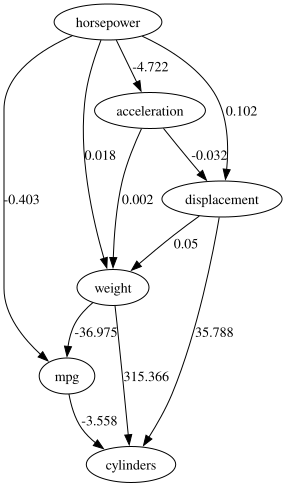

In [7]:
lingam_model = DirectLiNGAM()
lingam_model.fit(X)

adj_lingam = lingam_model.adjacency_matrix_
print("LiNGAM adjacency matrix shape:", adj_lingam.shape)

graph_lingam = make_graph(adj_lingam, feature_names)
graph_lingam

In [8]:
lingam_edges = edges_from_adj(adj_lingam, feature_names)
lingam_edges_sorted = lingam_edges.sort_values(
    "weight", key=lambda s: s.abs(), ascending=False
)

print("LiNGAM edges (sorted by |weight|):")
display(lingam_edges_sorted)

LiNGAM edges (sorted by |weight|):


,src,dst,weight
8,weight,cylinders,315.36622
7,weight,mpg,-36.97547
1,displacement,cylinders,35.78844
6,horsepower,acceleration,-4.72247
0,mpg,cylinders,-3.55808
3,horsepower,mpg,-0.40302
4,horsepower,displacement,0.10189
2,displacement,weight,0.05044
9,acceleration,displacement,-0.03153
5,horsepower,weight,0.01799


주요 엣지만 해석해보면:

- **weight → mpg (음수)**  
  - 무게가 증가할수록 연비가 감소하는 관계로,  
    “차량이 무거울수록 연비가 나빠진다”는 직관과 일치합니다.

- **horsepower → acceleration (음수)**  
  - `acceleration`은 0–60 mph까지 걸리는 시간이므로  
    값이 작을수록 가속 성능이 좋습니다.
  - 출력이 높을수록 가속시간이 줄어드는 방향은 도메인 지식과 잘 맞습니다.

- **horsepower → mpg (음수)**  
  - 출력이 높으면 연비에 부정적일 수 있다는 도메인 지식과 부합합니다.

- **weight → cylinders, displacement → cylinders 등 일부 엣지**는  
  - 실제 공학적 구조(`cylinders → displacement → weight`)와 반대 방향으로 추정되었습니다.

즉, LiNGAM은 연비·출력·가속·무게 사이의 관계를 어느 정도 합리적으로 포착하지만,  
모든 방향을 그대로 신뢰하기보다는 도메인 지식과 함께 검증할 필요가 있습니다.

### PC Algorithm

Depth=3, working on node 5: 100%|██████████| 6/6 [00:00<00:00, 2269.44it/s]

PC adjacency matrix shape: (6, 6)


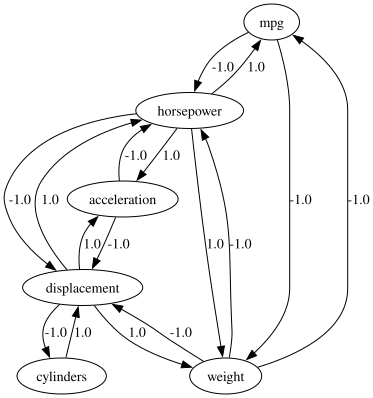

In [9]:
pc_result = pc(X, alpha=0.05)
pc_adj = pc_result.G.graph

print("PC adjacency matrix shape:", pc_adj.shape)

graph_pc = make_graph(pc_adj, feature_names)
graph_pc

In [10]:
pc_edges = edges_from_adj(pc_adj, feature_names)
pc_edges_sorted = pc_edges.sort_values(
    "weight", key=lambda s: s.abs(), ascending=False
)

print("PC edges:")
display(pc_edges_sorted)

PC edges:


,src,dst,weight
0,mpg,horsepower,-1.0
1,mpg,weight,-1.0
2,cylinders,displacement,1.0
3,displacement,cylinders,-1.0
4,displacement,horsepower,1.0
5,displacement,weight,1.0
6,displacement,acceleration,1.0
7,horsepower,mpg,1.0
8,horsepower,displacement,-1.0
9,horsepower,weight,1.0


- PC에서 나오는 `weight` 값(±1)은 LiNGAM의 회귀 계수와 달리 
  
  엣지 방향/존재 여부를 코드화한 값일 뿐, 효과 크기를 의미하지 않습니다.

- 어떤 변수 쌍에 엣지가 있고, 방향이 어떻게 나왔는지 LiNGAM 결과 및 도메인 지식과 비교합니다.

### GES

GES adjacency matrix shape: (6, 6)


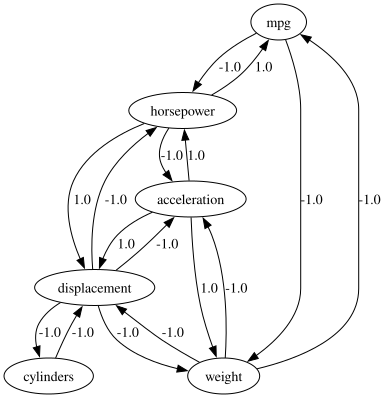

In [11]:
ges_result = ges(X)
ges_graph = ges_result["G"]
ges_adj = ges_graph.graph

print("GES adjacency matrix shape:", ges_adj.shape)

graph_ges = make_graph(ges_adj, feature_names)
graph_ges

In [12]:
ges_edges = edges_from_adj(ges_adj, feature_names)
ges_edges_sorted = ges_edges.sort_values(
    "weight", key=lambda s: s.abs(), ascending=False
)

print("GES edges:")
display(ges_edges_sorted)


GES edges:


,src,dst,weight
0,mpg,horsepower,-1.0
1,mpg,weight,-1.0
2,cylinders,displacement,-1.0
3,displacement,cylinders,-1.0
4,displacement,horsepower,-1.0
5,displacement,weight,-1.0
6,displacement,acceleration,-1.0
7,horsepower,mpg,1.0
8,horsepower,displacement,1.0
9,horsepower,acceleration,-1.0


### PC, GES 구조 리뷰

PC와 GES는 공통적으로

- `mpg`–`weight`
- `displacement`–`horsepower`–`weight`
- `displacement`–`cylinders`
- `horsepower`–`acceleration`

등, 연비·무게·배기량·출력·가속시간 사이의 상관 구조를 포착합니다.

하지만

- 동일한 변수 쌍에 대해 양방향 엣지가 나타나거나
- LiNGAM과 정반대 방향의 엣지가 나오는 등

Markov equivalence class 수준이라 명확한 인과 방향 해석이 어렵습니다.

따라서 방향성에 대한 해석은 도메인 지식과 함께 검토해야 합니다.

## Identify and Estimate

weight → mpg 인과 효과를 추정하는 두 가지 경로를 비교합니다.

1. LiNGAM이 제안한 DAG를 그대로 쓴 경우  
2. 도메인 지식으로 구성한 DAG를 쓴 경우

### LiNGAM based DAG

LiNGAM adjacency matrix를 `networkx.DiGraph`로 변환하여  
`DoWhy`의 `CausalModel`에 사용합니다.

In [13]:
def lingam_adj_to_nx(adj: np.ndarray, names):
    """
    LiNGAM adjacency matrix -> networkx.DiGraph 변환
    adj[i, j] != 0 이면 i -> j 방향의 edge를 추가한다.
    """
    G = nx.DiGraph()
    G.add_nodes_from(names)
    for i, src in enumerate(names):
        for j, dst in enumerate(names):
            w = float(adj[i, j])
            if abs(w) > 1e-8:
                G.add_edge(src, dst)
    return G

G_lingam = lingam_adj_to_nx(adj_lingam, feature_names)

print("Nodes:", list(G_lingam.nodes()))
print("Edges:", list(G_lingam.edges()))
print("Is DAG?:", nx.is_directed_acyclic_graph(G_lingam))

Nodes: ['mpg', 'cylinders', 'displacement', 'horsepower', 'weight', 'acceleration']
Edges: [('mpg', 'cylinders'), ('displacement', 'cylinders'), ('displacement', 'weight'), ('horsepower', 'mpg'), ('horsepower', 'displacement'), ('horsepower', 'weight'), ('horsepower', 'acceleration'), ('weight', 'mpg'), ('weight', 'cylinders'), ('acceleration', 'displacement'), ('acceleration', 'weight')]
Is DAG?: True


LiNGAM DAG를 그대로 신뢰한다고 가정하고,  
weight → mpg의 인과 효과를 추정합니다.

- treatment: `weight`
- outcome: `mpg`
- graph: `G_lingam` (LiNGAM으로부터 얻은 DAG)

In [20]:
treatment = "weight"
outcome = "mpg"

cm_lingam = CausalModel(
    data=data_small,
    treatment=treatment,
    outcome=outcome,
    graph=G_lingam,
)

identified_estimand_lingam = cm_lingam.identify_effect(
    proceed_when_unidentifiable=True
)

print("=== Identified estimand LiNGAM DAG ===")
print(identified_estimand_lingam)

=== Identified estimand LiNGAM DAG ===
Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
    d                       
─────────(E[mpg|horsepower])
d[weight]                   
Estimand assumption 1, Unconfoundedness: If U→{weight} and U→mpg then P(mpg|weight,horsepower,U) = P(mpg|weight,horsepower)

### Estimand : 2
Estimand name: iv
No such variable(s) found!

### Estimand : 3
Estimand name: frontdoor
No such variable(s) found!

### Estimand : 4
Estimand name: general_adjustment
Estimand expression:
    d                       
─────────(E[mpg|horsepower])
d[weight]                   
Estimand assumption 1, Unconfoundedness: If U→{weight} and U→mpg then P(mpg|weight,horsepower,U) = P(mpg|weight,horsepower)



In [21]:
estimate_lingam = cm_lingam.estimate_effect(
    identified_estimand_lingam,
    method_name="backdoor.linear_regression",
    control_value=0,
    treatment_value=1,
    confidence_intervals=True,
    test_significance=True,
)

print("=== Estimated causal effect LiNGAM DAG ===")
print(estimate_lingam)

=== Estimated causal effect LiNGAM DAG ===
*** Causal Estimate ***

## Identified estimand
Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
    d                       
─────────(E[mpg|horsepower])
d[weight]                   
Estimand assumption 1, Unconfoundedness: If U→{weight} and U→mpg then P(mpg|weight,horsepower,U) = P(mpg|weight,horsepower)

## Realized estimand
b: mpg~weight+horsepower
Target units: ate

## Estimate
Mean value: -0.005794157364803709
p-value: [0.]
95.0% confidence interval: [[-0.007 -0.005]]



### Domain Knowledge based DAG

Causal discovery 결과를 참고하여,
도메인 지식으로 DAG를 결정합니다.

- 엔진 크기와 구조
  - `cylinders → displacement`
  - `displacement → horsepower`

- 엔진/구조 → 무게
  - `cylinders → weight`
  - `displacement → weight`
  - `horsepower → weight`

- 무게 및 엔진 성능 → 연비
  - `weight → mpg`        (무거울수록 연비가 떨어짐)
  - `displacement → mpg`  (큰 엔진일수록 연비가 낮은 경향)
  - `horsepower → mpg`    (고출력 엔진은 연비가 낮을 가능성)

- 출력 → 가속 성능
  - `horsepower → acceleration`  (마력이 높을수록 가속 시간이 짧아짐)

In [22]:
gml_mpg_domain = """
graph [
  directed 1

  node [ id "mpg" label "mpg" ]
  node [ id "cylinders" label "cylinders" ]
  node [ id "displacement" label "displacement" ]
  node [ id "horsepower" label "horsepower" ]
  node [ id "weight" label "weight" ]
  node [ id "acceleration" label "acceleration" ]

  
  edge [ source "cylinders"    target "displacement" ]
  edge [ source "displacement" target "horsepower"   ]
  edge [ source "horsepower"   target "acceleration" ]

  
  edge [ source "cylinders"    target "weight" ]
  edge [ source "displacement" target "weight" ]
  edge [ source "horsepower"   target "weight" ]

  
  edge [ source "weight"       target "mpg" ]
  edge [ source "displacement" target "mpg" ]
  edge [ source "horsepower"   target "mpg" ]
]
"""

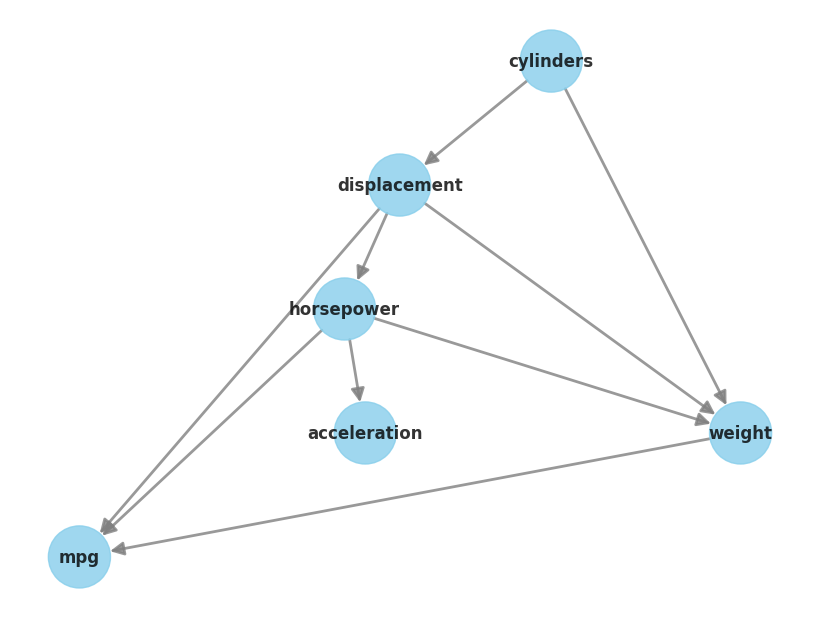

In [23]:
cm_domain = CausalModel(
    data=data_small,
    treatment="weight",
    outcome="mpg",
    graph=gml_mpg_domain
)

cm_domain.view_model(layout="dot")
display(cm_domain)

In [24]:
identified_estimand_domain = cm_domain.identify_effect(
    proceed_when_unidentifiable=True
)

print("=== Identified Estimand Domain DAG ===")
print(identified_estimand_domain)


=== Identified Estimand Domain DAG ===
Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
    d                                    
─────────(E[mpg|displacement,horsepower])
d[weight]                                
Estimand assumption 1, Unconfoundedness: If U→{weight} and U→mpg then P(mpg|weight,displacement,horsepower,U) = P(mpg|weight,displacement,horsepower)

### Estimand : 2
Estimand name: iv
No such variable(s) found!

### Estimand : 3
Estimand name: frontdoor
No such variable(s) found!

### Estimand : 4
Estimand name: general_adjustment
Estimand expression:
    d                                    
─────────(E[mpg|displacement,horsepower])
d[weight]                                
Estimand assumption 1, Unconfoundedness: If U→{weight} and U→mpg then P(mpg|weight,displacement,horsepower,U) = P(mpg|weight,displacement,horsepower)



In [25]:
estimate_domain = cm_domain.estimate_effect(
    identified_estimand_domain,
    method_name="backdoor.linear_regression",
    control_value=0,
    treatment_value=1,
    confidence_intervals=True,
)

print("=== Estimated Causal Effect Domain DAG ===")
print(estimate_domain)

=== Estimated Causal Effect Domain DAG ===
*** Causal Estimate ***

## Identified estimand
Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
    d                                    
─────────(E[mpg|displacement,horsepower])
d[weight]                                
Estimand assumption 1, Unconfoundedness: If U→{weight} and U→mpg then P(mpg|weight,displacement,horsepower,U) = P(mpg|weight,displacement,horsepower)

## Realized estimand
b: mpg~weight+displacement+horsepower
Target units: ate

## Estimate
Mean value: -0.005351592611027911
95.0% confidence interval: [[-0.007 -0.004]]

